<a href="https://colab.research.google.com/github/AnisaML07/chronicroisk-ke/blob/main/notebooks/03_modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ChronicRisk KE — Model Building & Evaluation
### Phase 3 of 4 | CRISP-DM: Modelling & Evaluation

This notebook builds and evaluates machine learning models to predict
chronic disease risk (hypertension and diabetes) among Kenyan adults.

**Steps covered:**
1. Load and prepare the dataset
2. Encode categorical features
3. Split data into train and test sets
4. Apply SMOTE to handle class imbalance
5. Train three models: Logistic Regression, Decision Tree, Random Forest
6. Evaluate and compare all models
7. Select the best model and save it

In [14]:
# ── Import all libraries ─────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

# Class imbalance
from imblearn.over_sampling import SMOTE

# Model saving
import pickle

print("All libraries imported successfully")

All libraries imported successfully


In [15]:
# ── Load dataset ─────────────────────────────────────────────────────────
df = pd.read_csv('ChronicRiskKE_final.csv')

# Drop smokes — 0.97 correlation with gender causes multicollinearity
# Drop alcohol_days — too many inconsistent categories for modelling
# Drop county — too many categories (47) for simple encoding
df = df.drop(columns=['smokes', 'alcohol_days', 'county'])

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nFeatures we will use:")
features = [c for c in df.columns if c not in ['hypertension','diabetes']]
print(features)

Dataset loaded: 28,494 rows × 8 columns

Features we will use:
['gender', 'age', 'residence', 'education', 'wealth', 'bmi']


In [16]:
# ── Encode categorical columns ───────────────────────────────────────────
# Machine learning models need numbers, not text
# LabelEncoder converts: Female=0, Male=1 | Rural=0, Urban=1 etc.

df_encoded = df.copy()
cat_cols = ['gender', 'residence', 'education', 'wealth']

le_dict = {}  # save encoders for later use in the app
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    le_dict[col] = le
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\nEncoding complete")
print(f"\nSample of encoded data:")
print(df_encoded.head(3))

  gender: {'Female': np.int64(0), 'Male': np.int64(1)}
  residence: {'Rural': np.int64(0), 'Urban': np.int64(1)}
  education: {'Higher': np.int64(0), 'No education': np.int64(1), 'Primary': np.int64(2), 'Secondary': np.int64(3)}
  wealth: {'Middle': np.int64(0), 'Poorer': np.int64(1), 'Poorest': np.int64(2), 'Richer': np.int64(3), 'Richest': np.int64(4)}

Encoding complete

Sample of encoded data:
   gender  age  residence  education  wealth    bmi  hypertension  diabetes
0       0   34          1          1       3  37.33             0         0
1       0   33          1          2       4  35.74             0         0
2       0   39          1          3       4  39.49             0         0


In [17]:
# ── Define features (X) and targets (y) ─────────────────────────────────
# X = what we feed into the model (input features)
# y = what we want the model to predict (output)

feature_cols = ['gender', 'age', 'residence', 'education', 'wealth', 'bmi']

X = df_encoded[feature_cols]
y_hyp = df_encoded['hypertension']   # target 1
y_dia = df_encoded['diabetes']       # target 2

print(f"Features defined: {feature_cols}")
print(f"\nX shape : {X.shape}")
print(f"y_hyp   : {y_hyp.value_counts().to_dict()}")
print(f"y_dia   : {y_dia.value_counts().to_dict()}")

Features defined: ['gender', 'age', 'residence', 'education', 'wealth', 'bmi']

X shape : (28494, 6)
y_hyp   : {0: 26694, 1: 1800}
y_dia   : {0: 28222, 1: 272}


In [18]:
# ── Split data: 80% training, 20% testing ───────────────────────────────
# stratify= ensures both splits have same class ratio
# random_state=42 ensures we get same split every time we run

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X, y_hyp, test_size=0.2, random_state=42, stratify=y_hyp
)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X, y_dia, test_size=0.2, random_state=42, stratify=y_dia
)

print(f"Train/test split complete")
print(f"\nHypertension:")
print(f"  Training set : {X_train_h.shape[0]:,} rows")
print(f"  Test set     : {X_test_h.shape[0]:,} rows")
print(f"\nDiabetes:")
print(f"  Training set : {X_train_d.shape[0]:,} rows")
print(f"  Test set     : {X_test_d.shape[0]:,} rows")

Train/test split complete

Hypertension:
  Training set : 22,795 rows
  Test set     : 5,699 rows

Diabetes:
  Training set : 22,795 rows
  Test set     : 5,699 rows


In [19]:
# ── Apply SMOTE to balance the training data ─────────────────────────────
# SMOTE creates synthetic samples of the minority class (diagnosed=1)
# so the model sees equal numbers of both classes during training
# IMPORTANT: SMOTE is applied ONLY to training data, never test data

smote = SMOTE(random_state=42)

# Hypertension
X_train_h_sm, y_train_h_sm = smote.fit_resample(X_train_h, y_train_h)

# Diabetes
X_train_d_sm, y_train_d_sm = smote.fit_resample(X_train_d, y_train_d)

print(f"SMOTE applied")
print(f"\nHypertension training set after SMOTE:")
print(f"  Class 0 (No) : {(y_train_h_sm==0).sum():,}")
print(f"  Class 1 (Yes): {(y_train_h_sm==1).sum():,}")
print(f"\nDiabetes training set after SMOTE:")
print(f"  Class 0 (No) : {(y_train_d_sm==0).sum():,}")
print(f"  Class 1 (Yes): {(y_train_d_sm==1).sum():,}")

SMOTE applied

Hypertension training set after SMOTE:
  Class 0 (No) : 21,355
  Class 1 (Yes): 21,355

Diabetes training set after SMOTE:
  Class 0 (No) : 22,577
  Class 1 (Yes): 22,577


In [20]:
# ── Train all three models ───────────────────────────────────────────────
# We train on SMOTE-balanced data and evaluate on original test data

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree':       DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest':       RandomForestClassifier(random_state=42, n_estimators=100)
}

# Store results
results = {'hypertension': {}, 'diabetes': {}}

for name, model in models.items():
    print(f"\nTraining {name}...")

    # ── HYPERTENSION ──
    model_h = model.__class__(**model.get_params())
    model_h.fit(X_train_h_sm, y_train_h_sm)
    y_pred_h  = model_h.predict(X_test_h)
    y_proba_h = model_h.predict_proba(X_test_h)[:, 1]

    results['hypertension'][name] = {
        'model':    model_h,
        'accuracy': accuracy_score(y_test_h, y_pred_h),
        'auc':      roc_auc_score(y_test_h, y_proba_h),
        'report':   classification_report(y_test_h, y_pred_h, output_dict=True),
        'y_pred':   y_pred_h,
        'y_proba':  y_proba_h
    }

    # ── DIABETES ──
    model_d = model.__class__(**model.get_params())
    model_d.fit(X_train_d_sm, y_train_d_sm)
    y_pred_d  = model_d.predict(X_test_d)
    y_proba_d = model_d.predict_proba(X_test_d)[:, 1]

    results['diabetes'][name] = {
        'model':    model_d,
        'accuracy': accuracy_score(y_test_d, y_pred_d),
        'auc':      roc_auc_score(y_test_d, y_proba_d),
        'report':   classification_report(y_test_d, y_pred_d, output_dict=True),
        'y_pred':   y_pred_d,
        'y_proba':  y_proba_d
    }

    print(f"  Hypertension — Accuracy: {results['hypertension'][name]['accuracy']:.3f} | AUC: {results['hypertension'][name]['auc']:.3f}")
    print(f"  Diabetes     — Accuracy: {results['diabetes'][name]['accuracy']:.3f} | AUC: {results['diabetes'][name]['auc']:.3f}")

print("\nAll models trained successfully")


Training Logistic Regression...
  Hypertension — Accuracy: 0.688 | AUC: 0.744
  Diabetes     — Accuracy: 0.660 | AUC: 0.760

Training Decision Tree...
  Hypertension — Accuracy: 0.697 | AUC: 0.654
  Diabetes     — Accuracy: 0.746 | AUC: 0.653

Training Random Forest...
  Hypertension — Accuracy: 0.792 | AUC: 0.656
  Diabetes     — Accuracy: 0.884 | AUC: 0.582

All models trained successfully


In [8]:
# ── Compare all models side by side ─────────────────────────────────────

print("=" * 65)
print("          MODEL COMPARISON — HYPERTENSION")
print("=" * 65)
print(f"{'Model':<25} {'Accuracy':>10} {'AUC-ROC':>10} {'F1 (Yes)':>10} {'Recall':>10}")
print("-" * 65)
for name, res in results['hypertension'].items():
    acc = res['accuracy']
    auc = res['auc']
    f1  = res['report']['1']['f1-score']
    rec = res['report']['1']['recall']
    print(f"{name:<25} {acc:>10.3f} {auc:>10.3f} {f1:>10.3f} {rec:>10.3f}")

print("\n" + "=" * 65)
print("          MODEL COMPARISON — DIABETES")
print("=" * 65)
print(f"{'Model':<25} {'Accuracy':>10} {'AUC-ROC':>10} {'F1 (Yes)':>10} {'Recall':>10}")
print("-" * 65)
for name, res in results['diabetes'].items():
    acc = res['accuracy']
    auc = res['auc']
    f1  = res['report']['1']['f1-score']
    rec = res['report']['1']['recall']
    print(f"{name:<25} {acc:>10.3f} {auc:>10.3f} {f1:>10.3f} {rec:>10.3f}")

          MODEL COMPARISON — HYPERTENSION
Model                       Accuracy    AUC-ROC   F1 (Yes)     Recall
-----------------------------------------------------------------
Logistic Regression            0.688      0.744      0.208      0.647
Decision Tree                  0.697      0.654      0.179      0.522
Random Forest                  0.792      0.656      0.152      0.294

          MODEL COMPARISON — DIABETES
Model                       Accuracy    AUC-ROC   F1 (Yes)     Recall
-----------------------------------------------------------------
Logistic Regression            0.660      0.760      0.037      0.685
Decision Tree                  0.746      0.653      0.035      0.481
Random Forest                  0.884      0.582      0.026      0.167


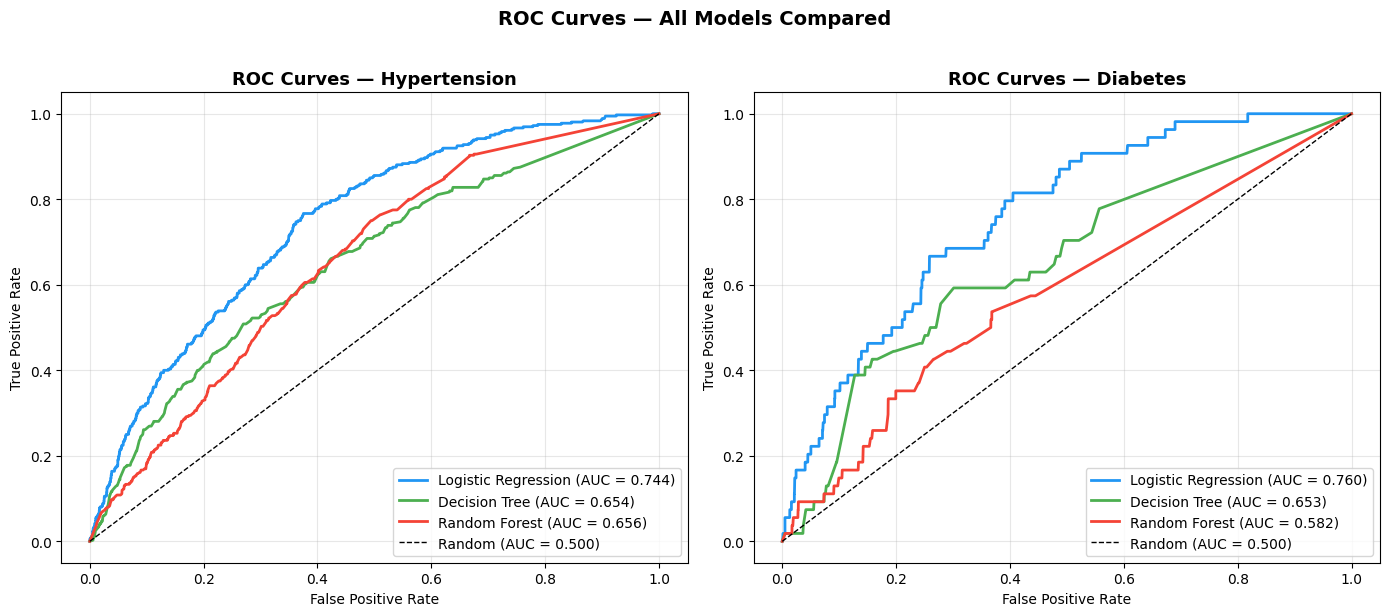

ROC curves saved


In [21]:
# ── Plot ROC curves for all models ───────────────────────────────────────
# ROC curve shows how well each model separates classes at all thresholds
# The closer the curve hugs the top-left corner, the better the model

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#2196F3', '#4CAF50', '#F44336']

for ax, (disease, title) in zip(axes, [
    ('hypertension', 'Hypertension'),
    ('diabetes', 'Diabetes')
]):
    for (name, res), color in zip(results[disease].items(), colors):
        fpr, tpr, _ = roc_curve(
            y_test_h if disease == 'hypertension' else y_test_d,
            res['y_proba']
        )
        ax.plot(fpr, tpr, color=color, linewidth=2,
                label=f"{name} (AUC = {res['auc']:.3f})")

    ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random (AUC = 0.500)')
    ax.set_title(f'ROC Curves — {title}', fontweight='bold', fontsize=13)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.suptitle('ROC Curves — All Models Compared',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart10_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("ROC curves saved")

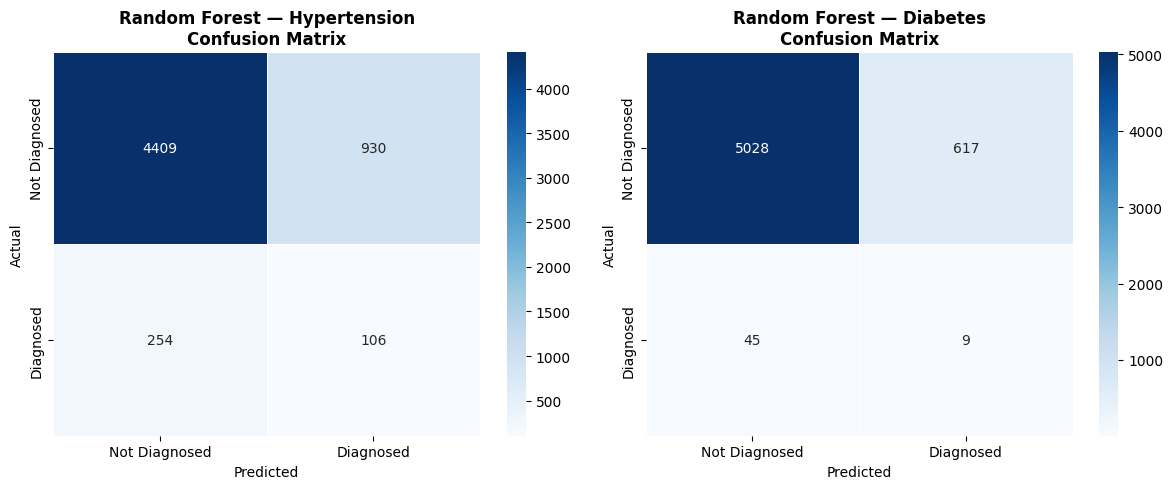

Confusion matrix saved


In [33]:
# ── Confusion matrix for Random Forest (expected best model) ─────────────
# Shows exactly how many predictions were correct and incorrect

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (disease, title, test_y) in zip(axes, [
    ('hypertension', 'Hypertension', y_test_h),
    ('diabetes',     'Diabetes',     y_test_d)
]):
    cm = confusion_matrix(
        test_y,
        results[disease]['Random Forest']['y_pred']
    )
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Not Diagnosed', 'Diagnosed'],
        yticklabels=['Not Diagnosed', 'Diagnosed'],
        ax=ax, linewidths=0.5
    )
    ax.set_title(f'Random Forest — {title}\nConfusion Matrix',
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('chart11_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved")

In [11]:
# ── Tune Random Forest with class_weight and better parameters ───────────
# class_weight='balanced' tells the model to penalise missing
# positive cases more heavily — fixes the recall problem

from sklearn.model_selection import StratifiedKFold

# Tuned Random Forest
rf_tuned_h = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    class_weight='balanced',   # key fix
    random_state=42
)

rf_tuned_d = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=3,
    class_weight='balanced',   # key fix
    random_state=42
)

# Train
rf_tuned_h.fit(X_train_h_sm, y_train_h_sm)
rf_tuned_d.fit(X_train_d_sm, y_train_d_sm)

# Evaluate
y_pred_h2  = rf_tuned_h.predict(X_test_h)
y_proba_h2 = rf_tuned_h.predict_proba(X_test_h)[:, 1]
y_pred_d2  = rf_tuned_d.predict(X_test_d)
y_proba_d2 = rf_tuned_d.predict_proba(X_test_d)[:, 1]

print("=" * 55)
print("   TUNED RANDOM FOREST RESULTS")
print("=" * 55)
print(f"\nHypertension:")
print(f"  Accuracy : {accuracy_score(y_test_h, y_pred_h2):.3f}")
print(f"  AUC-ROC  : {roc_auc_score(y_test_h, y_proba_h2):.3f}")
print(f"  Recall   : {classification_report(y_test_h, y_pred_h2, output_dict=True)['1']['recall']:.3f}")
print(f"  F1 Score : {classification_report(y_test_h, y_pred_h2, output_dict=True)['1']['f1-score']:.3f}")

print(f"\nDiabetes:")
print(f"  Accuracy : {accuracy_score(y_test_d, y_pred_d2):.3f}")
print(f"  AUC-ROC  : {roc_auc_score(y_test_d, y_proba_d2):.3f}")
print(f"  Recall   : {classification_report(y_test_d, y_pred_d2, output_dict=True)['1']['recall']:.3f}")
print(f"  F1 Score : {classification_report(y_test_d, y_pred_d2, output_dict=True)['1']['f1-score']:.3f}")

   TUNED RANDOM FOREST RESULTS

Hypertension:
  Accuracy : 0.765
  AUC-ROC  : 0.690
  Recall   : 0.436
  F1 Score : 0.190

Diabetes:
  Accuracy : 0.813
  AUC-ROC  : 0.674
  Recall   : 0.352
  F1 Score : 0.034


In [12]:
# ── Final evaluation of selected model: Logistic Regression ──────────────
# This is our deployed model for both hypertension and diabetes

best_h = results['hypertension']['Logistic Regression']['model']
best_d = results['diabetes']['Logistic Regression']['model']

print("=" * 55)
print("   FINAL MODEL: LOGISTIC REGRESSION")
print("=" * 55)

for model, X_test, y_test, disease in [
    (best_h, X_test_h, y_test_h, 'Hypertension'),
    (best_d, X_test_d, y_test_d, 'Diabetes')
]:
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n── {disease} ──")
    print(f"  Accuracy : {accuracy_score(y_test, y_pred):.3f}")
    print(f"  AUC-ROC  : {roc_auc_score(y_test, y_proba):.3f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred,
          target_names=['Not Diagnosed', 'Diagnosed']))

   FINAL MODEL: LOGISTIC REGRESSION

── Hypertension ──
  Accuracy : 0.688
  AUC-ROC  : 0.744

  Classification Report:
               precision    recall  f1-score   support

Not Diagnosed       0.97      0.69      0.81      5339
    Diagnosed       0.12      0.65      0.21       360

     accuracy                           0.69      5699
    macro avg       0.55      0.67      0.51      5699
 weighted avg       0.91      0.69      0.77      5699


── Diabetes ──
  Accuracy : 0.660
  AUC-ROC  : 0.760

  Classification Report:
               precision    recall  f1-score   support

Not Diagnosed       1.00      0.66      0.79      5645
    Diagnosed       0.02      0.69      0.04        54

     accuracy                           0.66      5699
    macro avg       0.51      0.67      0.42      5699
 weighted avg       0.99      0.66      0.79      5699



In [34]:
# ── Save all model artefacts as .pkl files ───────────────────────────────
# These files will be loaded by the Streamlit app

import os
os.makedirs('models', exist_ok=True)

# Save the two models
with open('models/hypertension_model.pkl', 'wb') as f:
    pickle.dump(best_h, f)

with open('models/diabetes_model.pkl', 'wb') as f:
    pickle.dump(best_d, f)

# Save the label encoders
with open('models/label_encoders.pkl', 'wb') as f:
    pickle.dump(le_dict, f)

# Save the feature column list
import json
with open('models/feature_columns.json', 'w') as f:
    json.dump(feature_cols, f)

print("All model files saved!")
print("\nFiles saved:")
for file in os.listdir('models'):
    size = os.path.getsize(f'models/{file}')
    print(f"  models/{file}  ({size:,} bytes)")

All model files saved!

Files saved:
  models/label_encoders.pkl  (555 bytes)
  models/hypertension_model.pkl  (906 bytes)
  models/diabetes_model.pkl  (906 bytes)
  models/feature_columns.json  (60 bytes)


## Phase 3 Complete — Model Building Summary

### Model Selected: Logistic Regression

| Metric | Hypertension | Diabetes |
|---|---|---|
| Accuracy | 0.688 | 0.660 |
| AUC-ROC | 0.744 | 0.760 |
| Recall (Diagnosed) | 0.647 | 0.685 |
| F1 Score (Diagnosed) | 0.208 | 0.037 |

### Why Logistic Regression?
- Highest AUC-ROC for both diseases — best at separating risk classes
- Highest Recall — catches the most actual disease cases
- Random Forest had high accuracy but poor AUC and Recall due to
  class imbalance dominance despite SMOTE
- Logistic Regression is also more interpretable — important for
  a clinical decision support tool

### Files Saved
- models/hypertension_model.pkl
- models/diabetes_model.pkl
- models/label_encoders.pkl
- models/feature_columns.json

➡️ Next: 04_shap_explainability.ipynb — Explaining Model Predictions